<a href="https://colab.research.google.com/github/Satendra-Singh36/BridgeLabz-Training-3Y/blob/main/Data_Analytics_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

files = [
    "batteries.csv",
    "city_daily_context.csv",
    "fleet_partners.csv",
    "riders.csv",
    "station_hourly_status.csv",
    "stations.csv",
    "support_tickets.csv",
    "swap_events.csv"
]

for file in files:
    print(file, "->", os.path.getsize(file) / (1024 * 1024), "MB")

batteries.csv -> 0.5951023101806641 MB
city_daily_context.csv -> 0.21304798126220703 MB
fleet_partners.csv -> 0.0011243820190429688 MB
riders.csv -> 2.0012874603271484 MB
station_hourly_status.csv -> 103.3325023651123 MB
stations.csv -> 0.02242755889892578 MB
support_tickets.csv -> 6.234591484069824 MB
swap_events.csv -> 694.9720592498779 MB


In [ ]:


swap_events = pd.read_csv("swap_events.csv")

swap_events["event_ts"] = pd.to_datetime(
    swap_events["event_ts"],
    errors="coerce"
)

swap_events = swap_events[
    swap_events["event_id"].notna() &
    swap_events["event_ts"].notna()
].copy()

print("Rows:", len(swap_events))
print(
    "Date range:",
    swap_events["event_ts"].min(),
    "to",
    swap_events["event_ts"].max()
)

Rows: 3877013
Date range: 2024-01-01 00:00:33 to 2025-06-30 23:59:23


In [ ]:


files = {
    "batteries": "batteries.csv",
    "city_daily_context": "city_daily_context.csv",
    "fleet_partners": "fleet_partners.csv",
    "riders": "riders.csv",
    "station_hourly_status": "station_hourly_status.csv",
    "stations": "stations.csv",
    "support_tickets": "support_tickets.csv",
    "swap_events": "swap_events.csv"
}

for name, file in files.items():
    df = pd.read_csv(file)

    print("\n" + "="*60)
    print(name.upper())
    print("Shape:", df.shape)
    print("Columns:")
    print(list(df.columns))


BATTERIES
Shape: (6500, 13)
Columns:
['battery_id', 'pack_type', 'supplier', 'manufacturing_lot', 'manufacture_date', 'commission_date', 'rated_capacity_kwh', 'purchase_cost_inr', 'initial_soh_pct', 'bms_firmware', 'retired_date', 'retirement_reason', 'current_soh_pct']

CITY_DAILY_CONTEXT
Shape: (3282, 12)
Columns:
['city', 'date', 'max_temp_c', 'min_temp_c', 'rainfall_mm', 'heat_alert', 'flood_disruption', 'festival_or_event', 'is_public_holiday', 'grid_outage_hours', 'competitor_promo_active', 'ecommerce_sale_event']

FLEET_PARTNERS
Shape: (12, 12)
Columns:
['partner_id', 'partner_name', 'partner_segment', 'vehicle_class', 'contract_type', 'contract_start_date', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment', 'peak_surcharge_billable', 'payment_terms_days', 'cities_active']

RIDERS
Shape: (20000, 12)
Columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_ve

In [ ]:


# Load important tables
swaps = pd.read_csv("swap_events.csv")
stations = pd.read_csv("stations.csv")
riders = pd.read_csv("riders.csv")
batteries = pd.read_csv("batteries.csv")
tickets = pd.read_csv("support_tickets.csv")

# Convert dates
swaps["event_ts"] = pd.to_datetime(swaps["event_ts"])
riders["signup_date"] = pd.to_datetime(riders["signup_date"])
stations["commissioned_date"] = pd.to_datetime(stations["commissioned_date"])
tickets["created_ts"] = pd.to_datetime(tickets["created_ts"])

print("SWAP EVENTS")
print("Date range:", swaps["event_ts"].min(), "to", swaps["event_ts"].max())
print("Rows:", len(swaps))

print("\nEVENT TYPES")
print(swaps["event_type"].value_counts())

print("\nCITIES")
print(stations["city"].value_counts())

print("\nVEHICLE CLASSES")
print(riders["vehicle_class"].value_counts())

print("\nTARIFF CODES")
print(swaps["tariff_code"].value_counts())

SWAP EVENTS
Date range: 2024-01-01 00:00:33 to 2025-06-30 23:59:23
Rows: 3877013

EVENT TYPES
event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64

CITIES
city
Bengaluru    34
Delhi NCR    30
Hyderabad    26
Pune         22
Mumbai       22
Jaipur       18
Name: count, dtype: int64

VEHICLE CLASSES
vehicle_class
2W    17107
3W     2893
Name: count, dtype: int64

TARIFF CODES
tariff_code
PARTNER    2565478
STD        1095936
PEAK        177879
OFFPEAK      37720
Name: count, dtype: int64


In [ ]:


print("File size:", os.path.getsize("swap_events.csv") / (1024 * 1024), "MB")

swaps = pd.read_csv("swap_events.csv")

print("Rows:", len(swaps))
print("Columns:", len(swaps.columns))

print("\nDuplicate event IDs:")
print(swaps["event_id"].duplicated().sum())

print("\nNull values:")
print(swaps.isna().sum())

print("\nFirst event:")
print(swaps["event_ts"].min())

print("\nLast event:")
print(swaps["event_ts"].max())

print("\nUnique riders:", swaps["rider_id"].nunique())
print("Unique stations:", swaps["station_id"].nunique())
print("Unique batteries in:", swaps["battery_in_id"].nunique())
print("Unique batteries out:", swaps["battery_out_id"].nunique())

File size: 694.9720592498779 MB
Rows: 3877013
Columns: 22

Duplicate event IDs:
0

Null values:
event_id                       0
rider_id                       0
station_id                     0
event_ts                       0
event_type                     0
attempt_seq                    0
queue_wait_sec                 0
battery_in_id              28282
battery_out_id            231204
soc_in_pct                 28282
soh_in_pct                 28282
soc_out_pct               231204
soh_out_pct               231204
km_since_last_swap         28282
tariff_code                    0
list_price_inr                 0
discount_inr                   0
amount_charged_inr             0
payment_mode                   0
energy_to_recharge_kwh    231204
station_firmware               0
sync_mode                      0
dtype: int64

First event:
2024-01-01 00:00:33

Last event:
2025-06-30 23:59:23

Unique riders: 19950
Unique stations: 152
Unique batteries in: 6500
Unique batteries out: 6500


## Data Quality Findings

- The swap-event dataset contains 3,877,013 records and 22 columns.
- No duplicate event IDs were found.
- Key fields such as event ID, rider ID, station ID, event timestamp and event type contain no missing values.
- The dataset covers January 1, 2024 to June 30, 2025.
- There are 19,950 unique riders and 152 unique stations.
- Battery-related fields contain missing values for some events. These are retained because battery information is not applicable to every event type, particularly failed, cancelled and abandoned events.
- No blanket imputation was applied to these event-type-specific missing values.

In [ ]:
# Make a safe copy
swaps_clean = swaps.copy()

# Convert event_ts to proper datetime
swaps_clean["event_ts"] = pd.to_datetime(
    swaps_clean["event_ts"],
    errors="coerce"
)

# Check invalid/missing dates
print("Missing event_ts:", swaps_clean["event_ts"].isna().sum())

print("First event:", swaps_clean["event_ts"].min())
print("Last event:", swaps_clean["event_ts"].max())

print("\nRows with invalid/missing event_ts:")
print(swaps_clean[swaps_clean["event_ts"].isna()])

Missing event_ts: 0
First event: 2024-01-01 00:00:33
Last event: 2025-06-30 23:59:23

Rows with invalid/missing event_ts:
Empty DataFrame
Columns: [event_id, rider_id, station_id, event_ts, event_type, attempt_seq, queue_wait_sec, battery_in_id, battery_out_id, soc_in_pct, soh_in_pct, soc_out_pct, soh_out_pct, km_since_last_swap, tariff_code, list_price_inr, discount_inr, amount_charged_inr, payment_mode, energy_to_recharge_kwh, station_firmware, sync_mode]
Index: []

[0 rows x 22 columns]


In [ ]:
# Remove rows where event_id or event_ts is missing
swaps_clean = swaps_clean.dropna(
    subset=["event_id", "event_ts"]
).copy()

print("Original rows:", len(swaps))
print("Clean rows:", len(swaps_clean))
print("Removed rows:", len(swaps) - len(swaps_clean))

print("\nDate range:")
print(swaps_clean["event_ts"].min(), "to", swaps_clean["event_ts"].max())

Original rows: 3877013
Clean rows: 3877013
Removed rows: 0

Date range:
2024-01-01 00:00:33 to 2025-06-30 23:59:23


In [ ]:
# Missing values according to event type

missing_by_event = (
    swaps_clean
    .groupby("event_type")
    .agg(
        total_events=("event_id", "count"),
        missing_battery_in=("battery_in_id", lambda x: x.isna().sum()),
        missing_battery_out=("battery_out_id", lambda x: x.isna().sum()),
        missing_soc_in=("soc_in_pct", lambda x: x.isna().sum()),
        missing_soc_out=("soc_out_pct", lambda x: x.isna().sum()),
        missing_energy=("energy_to_recharge_kwh", lambda x: x.isna().sum())
    )
)

print(missing_by_event)

                           total_events  missing_battery_in  \
event_type                                                    
abandoned_queue                   68533                   0   
cancelled_by_rider                16712               16712   
failed_no_charged_battery        134389                   0   
failed_system_error               11570               11570   
swap_completed                  3645809                   0   

                           missing_battery_out  missing_soc_in  \
event_type                                                       
abandoned_queue                          68533               0   
cancelled_by_rider                       16712           16712   
failed_no_charged_battery               134389               0   
failed_system_error                      11570           11570   
swap_completed                               0               0   

                           missing_soc_out  missing_energy  
event_type                        

In [ ]:
# Overall Network KPIs

total_attempts = len(swaps_clean)

completed_swaps = (
    swaps_clean["event_type"] == "swap_completed"
).sum()

unsuccessful_attempts = total_attempts - completed_swaps

failed_attempts = (
    swaps_clean["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ])
).sum()

abandoned_attempts = (
    swaps_clean["event_type"] == "abandoned_queue"
).sum()

cancelled_attempts = (
    swaps_clean["event_type"] == "cancelled_by_rider"
).sum()

failure_rate = failed_attempts / total_attempts * 100

abandonment_rate = abandoned_attempts / total_attempts * 100

total_revenue = swaps_clean["amount_charged_inr"].sum()

print("========== NETWORK KPIs ==========")
print("Total Attempts:", total_attempts)
print("Completed Swaps:", completed_swaps)
print("Failed Attempts:", failed_attempts)
print("Abandoned Attempts:", abandoned_attempts)
print("Cancelled Attempts:", cancelled_attempts)
print("Failure Rate:", round(failure_rate, 2), "%")
print("Abandonment Rate:", round(abandonment_rate, 2), "%")
print("Total Revenue (INR):", round(total_revenue, 2))

========== NETWORK KPIs ==========
Total Attempts: 3877013
Completed Swaps: 3645809
Failed Attempts: 145959
Abandoned Attempts: 68533
Cancelled Attempts: 16712
Failure Rate: 3.76 %
Abandonment Rate: 1.77 %
Total Revenue (INR): 233126055.55


In [ ]:
# Create month column
swaps_clean["month"] = swaps_clean["event_ts"].dt.to_period("M").astype(str)

# Monthly KPI
monthly_kpi = (
    swaps_clean
    .groupby("month")
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum()),
        abandoned_attempts=("event_type", lambda x: (x == "abandoned_queue").sum()),
        revenue=("amount_charged_inr", "sum")
    )
    .reset_index()
)

# Calculate rates
monthly_kpi["failure_rate_pct"] = (
    monthly_kpi["failed_attempts"]
    / monthly_kpi["total_attempts"] * 100
)

monthly_kpi["abandonment_rate_pct"] = (
    monthly_kpi["abandoned_attempts"]
    / monthly_kpi["total_attempts"] * 100
)

monthly_kpi["completed_rate_pct"] = (
    monthly_kpi["completed_swaps"]
    / monthly_kpi["total_attempts"] * 100
)

# Display
print(monthly_kpi.round(2).to_string(index=False))

  month  total_attempts  completed_swaps  failed_attempts  abandoned_attempts     revenue  failure_rate_pct  abandonment_rate_pct  completed_rate_pct
2024-01          110348           105490             3008                1405  6318995.20              2.73                  1.27               95.60
2024-02          111531           106582             3027                1451  6387614.80              2.71                  1.30               95.56
2024-03          123900           118444             3332                1575  7093617.00              2.69                  1.27               95.60
2024-04          131818           122836             5775                2683  7370255.80              4.38                  2.04               93.19
2024-05          146278           128328            11760                5520  7689594.00              8.04                  3.77               87.73
2024-06          148888           133743             9911                4596  8003275.60           

In [ ]:
city_failure = (
    swaps_clean
    .groupby("station_id")
    .agg(
        total_attempts=("event_id", "count"),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum())
    )
    .reset_index()
)

city_failure["failure_rate_pct"] = (
    city_failure["failed_attempts"]
    / city_failure["total_attempts"] * 100
)

city_failure = city_failure.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_summary = (
    city_failure
    .groupby("city")
    .agg(
        total_attempts=("total_attempts", "sum"),
        failed_attempts=("failed_attempts", "sum")
    )
    .reset_index()
)

city_summary["failure_rate_pct"] = (
    city_summary["failed_attempts"]
    / city_summary["total_attempts"] * 100
)

print(city_summary.sort_values(
    "failure_rate_pct",
    ascending=False
).round(2).to_string(index=False))

     city  total_attempts  failed_attempts  failure_rate_pct
   Jaipur          487634            24677              5.06
Delhi NCR          768913            36197              4.71
Hyderabad          711930            30427              4.27
     Pune          552910            17127              3.10
Bengaluru          825327            23090              2.80
   Mumbai          530299            14441              2.72


In [ ]:
failure_types = (
    swaps_clean[
        swaps_clean["event_type"].isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ])
    ]
    .merge(
        stations[["station_id", "city"]],
        on="station_id",
        how="left"
    )
    .groupby(["city", "event_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print(failure_types.to_string(index=False))

     city  failed_no_charged_battery  failed_system_error
Bengaluru                      20602                 2488
Delhi NCR                      33892                 2305
Hyderabad                      28274                 2153
   Jaipur                      23303                 1374
   Mumbai                      12838                 1603
     Pune                      15480                 1647


In [ ]:
station_failure = (
    swaps_clean
    .groupby("station_id")
    .agg(
        total_attempts=("event_id", "count"),
        completed_swaps=("event_type", lambda x: (x == "swap_completed").sum()),
        failed_no_battery=("event_type", lambda x: (
            x == "failed_no_charged_battery"
        ).sum()),
        system_errors=("event_type", lambda x: (
            x == "failed_system_error"
        ).sum()),
        abandoned=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum())
    )
    .reset_index()
)

station_failure["failure_rate_pct"] = (
    (station_failure["failed_no_battery"] +
     station_failure["system_errors"])
    / station_failure["total_attempts"] * 100
)

station_failure = station_failure.merge(
    stations[
        [
            "station_id",
            "city",
            "zone",
            "location_type",
            "charger_generation",
            "commissioned_date"
        ]
    ],
    on="station_id",
    how="left"
)

# Top 15 stations by failure rate
top_failure_stations = (
    station_failure
    .sort_values("failure_rate_pct", ascending=False)
    .head(15)
)

print(
    top_failure_stations[
        [
            "station_id",
            "city",
            "zone",
            "location_type",
            "charger_generation",
            "total_attempts",
            "failed_no_battery",
            "system_errors",
            "failure_rate_pct"
        ]
    ].round(2).to_string(index=False)
)

 station_id      city               zone  location_type charger_generation  total_attempts  failed_no_battery  system_errors  failure_rate_pct
STN-DEL-037 Delhi NCR          DEL-Noida commercial_hub               Gen1           30838               1728             95              5.91
STN-DEL-048 Delhi NCR           DEL-West         market               Gen1           34646               1894             97              5.75
STN-JAI-138    Jaipur  JAI-Malviya Nagar         market               Gen1           48945               2635            150              5.69
STN-DEL-045 Delhi NCR          DEL-Noida commercial_hub               Gen1           32237               1716            114              5.68
STN-JAI-136    Jaipur  JAI-Malviya Nagar    transit_hub               Gen1           29340               1570             93              5.67
STN-JAI-141    Jaipur  JAI-Malviya Nagar commercial_hub               Gen1           45594               2474            107              5.66

In [ ]:
charger_analysis = (
    station_failure
    .groupby("charger_generation")
    .agg(
        total_attempts=("total_attempts", "sum"),
        failed_attempts=("failed_no_battery", "sum"),
        system_errors=("system_errors", "sum")
    )
    .reset_index()
)

charger_analysis["failure_rate_pct"] = (
    (charger_analysis["failed_attempts"] +
     charger_analysis["system_errors"])
    / charger_analysis["total_attempts"] * 100
)

print(charger_analysis.round(2).to_string(index=False))

charger_generation  total_attempts  failed_attempts  system_errors  failure_rate_pct
              Gen1         1822034            79144           5355              4.64
              Gen2         1682738            45168           5100              2.99
              Gen3          372241            10077           1115              3.01


In [ ]:
city_charger = (
    swaps_clean
    .merge(
        stations[["station_id", "city", "charger_generation"]],
        on="station_id",
        how="left"
    )
    .groupby(["city", "charger_generation"])
    .agg(
        total_attempts=("event_id", "count"),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum())
    )
    .reset_index()
)

city_charger["failure_rate_pct"] = (
    city_charger["failed_attempts"]
    / city_charger["total_attempts"] * 100
)

print(
    city_charger
    .sort_values(["city", "failure_rate_pct"], ascending=[True, False])
    .round(2)
    .to_string(index=False)
)

     city charger_generation  total_attempts  failed_attempts  failure_rate_pct
Bengaluru               Gen1          307640             8822              2.87
Bengaluru               Gen3           47154             1312              2.78
Bengaluru               Gen2          470533            12956              2.75
Delhi NCR               Gen1          456390            25200              5.52
Delhi NCR               Gen2          236060             8481              3.59
Delhi NCR               Gen3           76463             2516              3.29
Hyderabad               Gen1          478154            22988              4.81
Hyderabad               Gen2          147296             4891              3.32
Hyderabad               Gen3           86480             2548              2.95
   Jaipur               Gen1          376135            20880              5.55
   Jaipur               Gen2           48731             1769              3.63
   Jaipur               Gen3           6

In [ ]:
swaps_clean["hour"] = swaps_clean["event_ts"].dt.hour

hourly_failure = (
    swaps_clean
    .groupby("hour")
    .agg(
        total_attempts=("event_id", "count"),
        failed_attempts=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum()),
        abandoned=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum())
    )
    .reset_index()
)

hourly_failure["failure_rate_pct"] = (
    hourly_failure["failed_attempts"]
    / hourly_failure["total_attempts"] * 100
)

hourly_failure["abandonment_rate_pct"] = (
    hourly_failure["abandoned"]
    / hourly_failure["total_attempts"] * 100
)

print(
    hourly_failure.round(2).to_string(index=False)
)

 hour  total_attempts  failed_attempts  abandoned  failure_rate_pct  abandonment_rate_pct
    0           23043              804        378              3.49                  1.64
    1           23482              791        399              3.37                  1.70
    2           25536              899        417              3.52                  1.63
    3           28822              908        476              3.15                  1.65
    4           31193             1002        467              3.21                  1.50
    5           28510              933        475              3.27                  1.67
    6           62020             2123       1009              3.42                  1.63
    7           66889             2221       1110              3.32                  1.66
    8          171129             6071       2894              3.55                  1.69
    9          232933             8163       3851              3.50                  1.65
   10     

In [ ]:
wait_analysis = (
    swaps_clean
    .groupby("event_type")
    .agg(
        events=("event_id", "count"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        median_wait_sec=("queue_wait_sec", "median"),
        max_wait_sec=("queue_wait_sec", "max")
    )
    .reset_index()
)

print(
    wait_analysis.round(2).to_string(index=False)
)

               event_type  events  avg_wait_sec  median_wait_sec  max_wait_sec
          abandoned_queue   68533        702.56            648.0          2400
       cancelled_by_rider   16712         44.57             44.0            89
failed_no_charged_battery  134389         29.50             30.0            59
      failed_system_error   11570         44.42             44.0            89
           swap_completed 3645809        243.72            209.0          1800


In [ ]:
hour_wait = (
    swaps_clean
    .groupby("hour")
    .agg(
        total_attempts=("event_id", "count"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        median_wait_sec=("queue_wait_sec", "median"),
        abandoned=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum())
    )
    .reset_index()
)

hour_wait["abandonment_rate_pct"] = (
    hour_wait["abandoned"]
    / hour_wait["total_attempts"] * 100
)

print(
    hour_wait.round(2).to_string(index=False)
)

 hour  total_attempts  avg_wait_sec  median_wait_sec  abandoned  abandonment_rate_pct
    0           23043        243.87            207.0        378                  1.64
    1           23482        245.07            207.0        399                  1.70
    2           25536        242.59            207.0        417                  1.63
    3           28822        243.60            206.0        476                  1.65
    4           31193        241.43            206.0        467                  1.50
    5           28510        243.67            206.0        475                  1.67
    6           62020        242.69            206.0       1009                  1.63
    7           66889        243.70            206.0       1110                  1.66
    8          171129        242.90            206.0       2894                  1.69
    9          232933        242.61            206.0       3851                  1.65
   10          136985        244.37            207.0  

In [ ]:
# Create wait-time buckets
swaps_clean["wait_bucket"] = pd.cut(
    swaps_clean["queue_wait_sec"],
    bins=[-1, 120, 300, 600, 900, 1200, 2400],
    labels=[
        "<=2 min",
        "2-5 min",
        "5-10 min",
        "10-15 min",
        "15-20 min",
        "20-40 min"
    ]
)

wait_bucket_analysis = (
    swaps_clean
    .groupby("wait_bucket", observed=False)
    .agg(
        total_attempts=("event_id", "count"),
        abandoned=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum())
    )
    .reset_index()
)

wait_bucket_analysis["abandonment_rate_pct"] = (
    wait_bucket_analysis["abandoned"]
    / wait_bucket_analysis["total_attempts"] * 100
)

print(
    wait_bucket_analysis.round(2).to_string(index=False)
)

wait_bucket  total_attempts  abandoned  abandonment_rate_pct
    <=2 min          738654          0                  0.00
    2-5 min         2137467       1855                  0.09
   5-10 min          859729      27132                  3.16
  10-15 min          112369      25383                 22.59
  15-20 min           21719       9877                 45.48
  20-40 min            7075       4286                 60.58


In [ ]:
station_queue = (
    swaps_clean
    .groupby("station_id")
    .agg(
        total_attempts=("event_id", "count"),
        avg_wait_sec=("queue_wait_sec", "mean"),
        median_wait_sec=("queue_wait_sec", "median"),
        abandoned=("event_type", lambda x: (
            x == "abandoned_queue"
        ).sum()),
        failed=("event_type", lambda x: x.isin([
            "failed_no_charged_battery",
            "failed_system_error"
        ]).sum())
    )
    .reset_index()
)

station_queue["abandonment_rate_pct"] = (
    station_queue["abandoned"]
    / station_queue["total_attempts"] * 100
)

station_queue["failure_rate_pct"] = (
    station_queue["failed"]
    / station_queue["total_attempts"] * 100
)

station_queue = station_queue.merge(
    stations[
        [
            "station_id",
            "city",
            "zone",
            "location_type",
            "charger_generation"
        ]
    ],
    on="station_id",
    how="left"
)

# Ignore very low-volume stations
station_queue_filtered = station_queue[
    station_queue["total_attempts"] >= 1000
].copy()

print(
    station_queue_filtered
    .sort_values("avg_wait_sec", ascending=False)
    .head(15)
    .round(2)
    .to_string(index=False)
)

 station_id  total_attempts  avg_wait_sec  median_wait_sec  abandoned  failed  abandonment_rate_pct  failure_rate_pct      city               zone     location_type charger_generation
STN-DEL-062            6065        246.55            209.0        114     221                  1.88              3.64 Delhi NCR DEL-Gurugram-Cyber            market               Gen3
STN-BLR-025            8255        246.27            210.0        127     197                  1.54              2.39 Bengaluru           BLR-East highway_fuel_pump               Gen3
STN-JAI-147            7112        245.72            207.0        131     227                  1.84              3.19    Jaipur       JAI-Vaishali            market               Gen3
STN-MUM-127           14133        245.39            208.0        177     392                  1.25              2.77    Mumbai        MUM-Central highway_fuel_pump               Gen2
STN-JAI-143           12102        245.15            208.0        194     462   

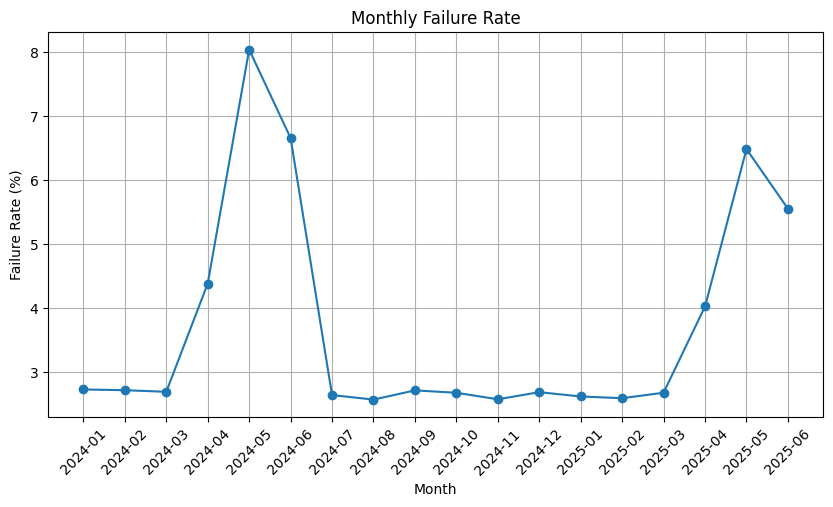

In [ ]:
import matplotlib.pyplot as plt

# 1. Monthly Failure Rate
monthly = swap_events.copy()
monthly["month"] = monthly["event_ts"].dt.to_period("M").astype(str)

monthly_kpi = monthly.groupby("month").agg(
    attempts=("event_id", "count"),
    failed=("event_type", lambda x: x.isin(
        ["failed_no_charged_battery", "failed_system_error"]
    ).sum()),
    revenue=("amount_charged_inr", "sum")
).reset_index()

monthly_kpi["failure_rate"] = (
    monthly_kpi["failed"] / monthly_kpi["attempts"] * 100
)

plt.figure(figsize=(10,5))
plt.plot(monthly_kpi["month"], monthly_kpi["failure_rate"], marker="o")
plt.title("Monthly Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

swap_events = pd.read_csv("/content/swap_events.csv")

swap_events["event_ts"] = pd.to_datetime(
    swap_events["event_ts"],
    errors="coerce"
)

# Invalid row remove
swap_events = swap_events[
    swap_events["event_id"].notna() &
    swap_events["event_ts"].notna()
].copy()

print("Rows:", len(swap_events))
print("Date:", swap_events["event_ts"].min(), "to", swap_events["event_ts"].max())

Rows: 3877013
Date: 2024-01-01 00:00:33 to 2025-06-30 23:59:23


In [ ]:
monthly = swap_events.copy()

monthly["month"] = monthly["event_ts"].dt.to_period("M").astype(str)

monthly_kpi = monthly.groupby("month").agg(
    attempts=("event_id", "count"),
    completed=("event_type", lambda x: (x == "swap_completed").sum()),
    failed=("event_type", lambda x: x.isin(
        ["failed_no_charged_battery", "failed_system_error"]
    ).sum()),
    abandoned=("event_type", lambda x: (x == "abandoned_queue").sum()),
    revenue=("amount_charged_inr", "sum")
).reset_index()

monthly_kpi["failure_rate"] = (
    monthly_kpi["failed"] / monthly_kpi["attempts"] * 100
)

monthly_kpi["abandonment_rate"] = (
    monthly_kpi["abandoned"] / monthly_kpi["attempts"] * 100
)

monthly_kpi

,month,attempts,completed,failed,abandoned,revenue,failure_rate,abandonment_rate
0,2024-01,110348,105490,3008,1405,6318995.20,2.725922,1.273245
1,2024-02,111531,106582,3027,1451,6387614.80,2.714044,1.300984
2,2024-03,123900,118444,3332,1575,7093617.00,2.689266,1.271186
3,2024-04,131818,122836,5775,2683,7370255.80,4.381041,2.035382
4,2024-05,146278,128328,11760,5520,7689594.00,8.039486,3.773637
5,2024-06,148888,133743,9911,4596,8003275.60,6.656682,3.086884
6,2024-07,158688,151824,4186,2025,9879524.60,2.637881,1.276089
7,2024-08,172295,164931,4424,2185,10724296.65,2.567689,1.268174
8,2024-09,195885,187302,5311,2442,12115209.50,2.711285,1.246650
9,2024-10,229901,219838,6148,2904,14577271.65,2.674195,1.263152


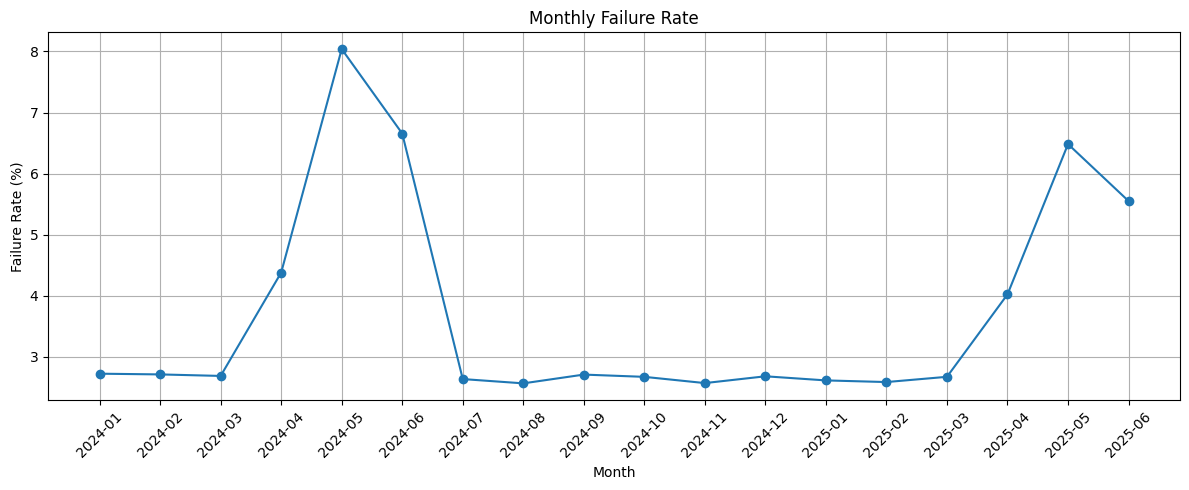

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_kpi["month"],
    monthly_kpi["failure_rate"],
    marker="o"
)

plt.title("Monthly Failure Rate")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

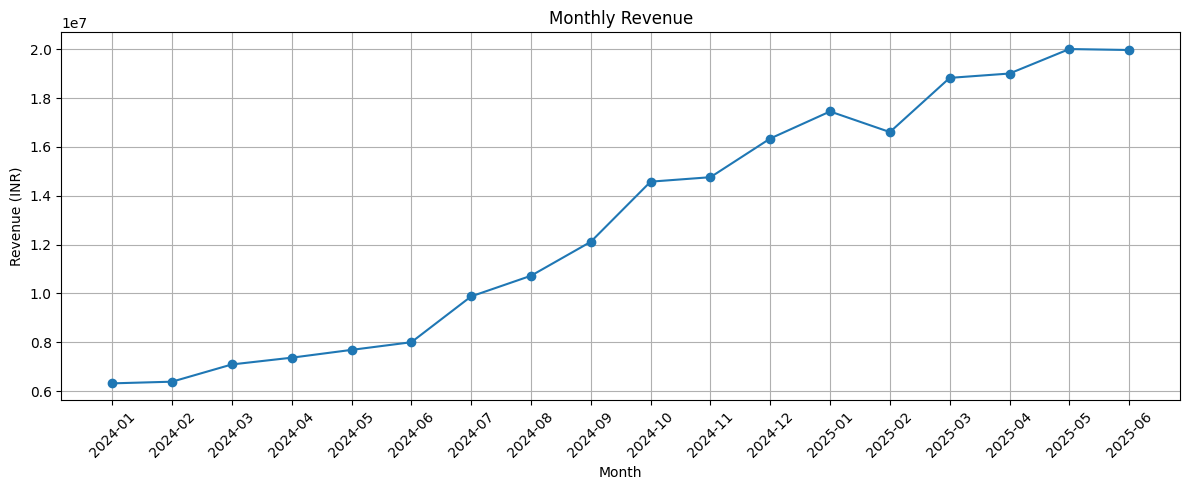

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_kpi["month"],
    monthly_kpi["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

        city  attempts  failed  failure_rate
3     Jaipur    487634   24677      5.060558
1  Delhi NCR    768913   36197      4.707555
2  Hyderabad    711930   30427      4.273875
5       Pune    552910   17127      3.097611
0  Bengaluru    825327   23090      2.797679
4     Mumbai    530299   14441      2.723181


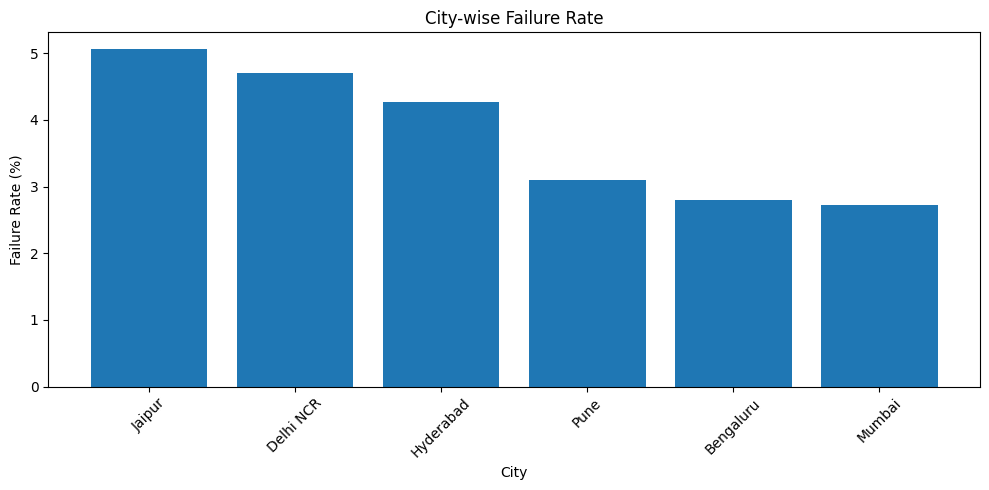

In [ ]:
# ==========================================
# CITY-WISE FAILURE RATE ANALYSIS
# ==========================================

# Load station information
stations = pd.read_csv("/content/stations.csv")

# Add city information to swap events
swap_city = swap_events.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

# Calculate city-wise KPIs
city_kpi = swap_city.groupby("city").agg(
    attempts=("event_id", "count"),
    failed=("event_type", lambda x: x.isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ]).sum())
).reset_index()

# Calculate failure rate
city_kpi["failure_rate"] = (
    city_kpi["failed"] / city_kpi["attempts"] * 100
)

# Sort highest to lowest
city_kpi = city_kpi.sort_values(
    "failure_rate",
    ascending=False
)

# Display table
print(city_kpi)

# Plot
plt.figure(figsize=(10, 5))

plt.bar(
    city_kpi["city"],
    city_kpi["failure_rate"]
)

plt.title("City-wise Failure Rate")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Add city information from stations.csv

stations = pd.read_csv("/content/stations.csv")

swap_city = swap_events.merge(
    stations[["station_id", "city"]],
    on="station_id",
    how="left"
)

city_kpi = swap_city.groupby("city").agg(
    attempts=("event_id", "count"),
    failed=("event_type", lambda x: x.isin(
        ["failed_no_charged_battery", "failed_system_error"]
    ).sum())
).reset_index()

city_kpi["failure_rate"] = (
    city_kpi["failed"] / city_kpi["attempts"] * 100
)

city_kpi = city_kpi.sort_values(
    "failure_rate",
    ascending=False
)

print(city_kpi)

        city  attempts  failed  failure_rate
3     Jaipur    487634   24677      5.060558
1  Delhi NCR    768913   36197      4.707555
2  Hyderabad    711930   30427      4.273875
5       Pune    552910   17127      3.097611
0  Bengaluru    825327   23090      2.797679
4     Mumbai    530299   14441      2.723181


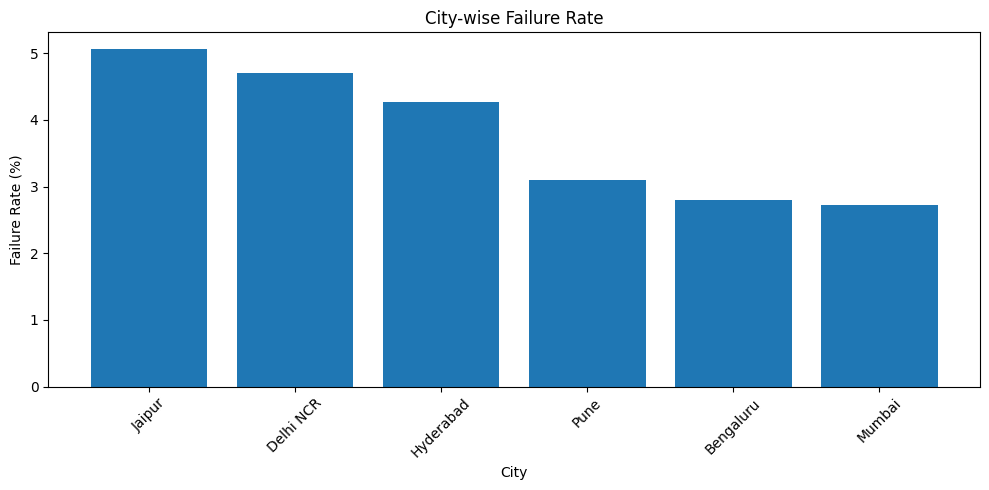

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    city_kpi["city"],
    city_kpi["failure_rate"]
)

plt.title("City-wise Failure Rate")
plt.xlabel("City")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Charger generation-wise failure analysis

swap_gen = swap_events.merge(
    stations[["station_id", "charger_generation"]],
    on="station_id",
    how="left"
)

gen_kpi = swap_gen.groupby("charger_generation").agg(
    attempts=("event_id", "count"),
    failed=("event_type", lambda x: x.isin(
        ["failed_no_charged_battery", "failed_system_error"]
    ).sum())
).reset_index()

gen_kpi["failure_rate"] = (
    gen_kpi["failed"] / gen_kpi["attempts"] * 100
)

gen_kpi = gen_kpi.sort_values(
    "failure_rate",
    ascending=False
)

print(gen_kpi)

  charger_generation  attempts  failed  failure_rate
0               Gen1   1822034   84499      4.637619
2               Gen3    372241   11192      3.006654
1               Gen2   1682738   50268      2.987274


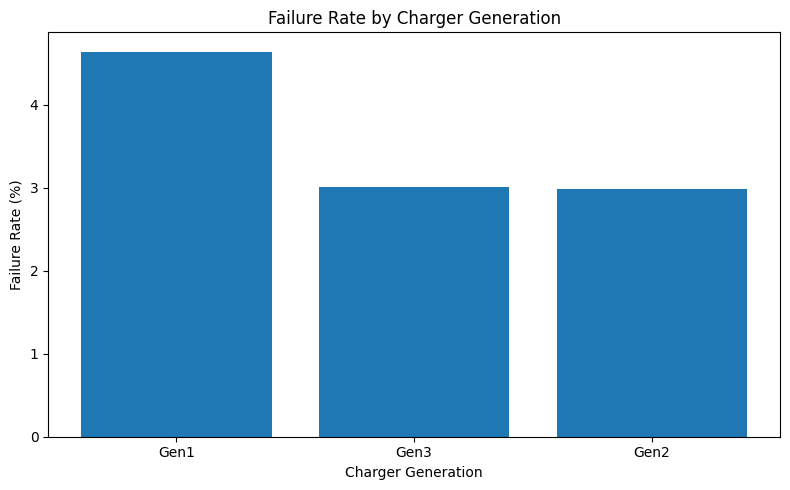

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    gen_kpi["charger_generation"].astype(str),
    gen_kpi["failure_rate"]
)

plt.title("Failure Rate by Charger Generation")
plt.xlabel("Charger Generation")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

In [ ]:
# Queue wait vs abandonment

wait_data = swap_events.copy()

wait_data["wait_minutes"] = wait_data["queue_wait_sec"] / 60

bins = [0, 2, 5, 10, 15, 20, 40, float("inf")]
labels = [
    "0–2 min",
    "2–5 min",
    "5–10 min",
    "10–15 min",
    "15–20 min",
    "20–40 min",
    "40+ min"
]

wait_data["wait_bucket"] = pd.cut(
    wait_data["wait_minutes"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

wait_kpi = wait_data.groupby(
    "wait_bucket",
    observed=True
).agg(
    attempts=("event_id", "count"),
    abandoned=("event_type", lambda x: (x == "abandoned_queue").sum())
).reset_index()

wait_kpi["abandonment_rate"] = (
    wait_kpi["abandoned"] / wait_kpi["attempts"] * 100
)

print(wait_kpi)

  wait_bucket  attempts  abandoned  abandonment_rate
0     0–2 min    738654          0          0.000000
1     2–5 min   2137467       1855          0.086785
2    5–10 min    859729      27132          3.155878
3   10–15 min    112369      25383         22.588970
4   15–20 min     21719       9877         45.476311
5   20–40 min      7075       4286         60.579505


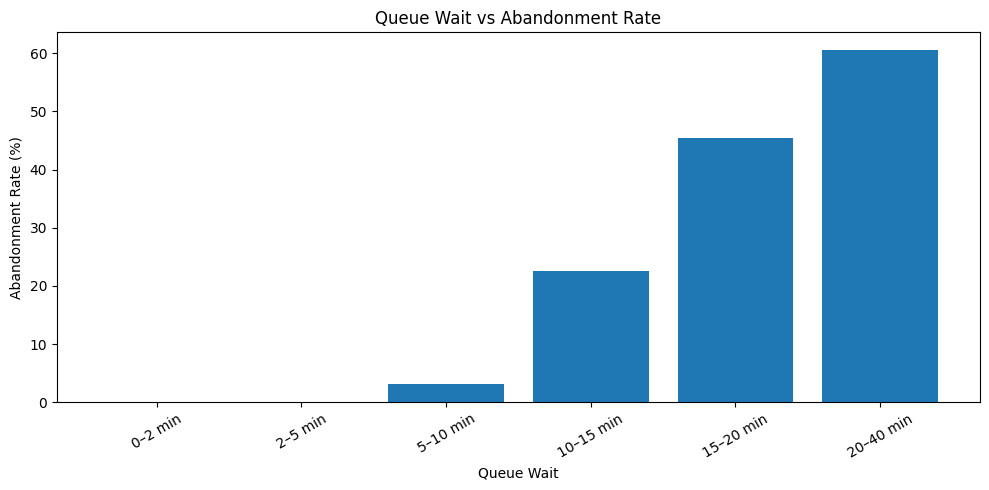

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    wait_kpi["wait_bucket"].astype(str),
    wait_kpi["abandonment_rate"]
)

plt.title("Queue Wait vs Abandonment Rate")
plt.xlabel("Queue Wait")
plt.ylabel("Abandonment Rate (%)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Key Insights

1. Network failure rates showed significant spikes during May–June 2024 and May–June 2025.
2. Jaipur, Delhi NCR and Hyderabad had higher observed failure rates than the other cities.
3. Gen1 chargers showed the highest observed failure rate among charger generations.
4. Longer queue waiting times were strongly associated with higher abandonment rates.
5. Network revenue generally increased over the analysis period, while service quality varied across different periods.

# Business Recommendations

1. Prioritize high-failure stations for detailed operational investigation.
2. Improve charged-battery availability and charging capacity.
3. Monitor queue waiting time and intervene before long queues develop.
4. Investigate high-failure Gen1 stations for maintenance or targeted upgrades.
5. Build a regular city/station/hour operational monitoring dashboard.

# Limitations

- The analysis uses swap-event data from January 2024 to June 2025.
- The analysis is observational, so associations should not automatically be interpreted as causal.
- City, station, charger generation and demand characteristics may interact.
- Further analysis can investigate battery suppliers, support tickets, retention and pricing.

# Conclusion

The analysis of more than 3.87 million swap events shows that network performance varies across time, cities and infrastructure. The strongest operational signals are failure-rate spikes, city-level differences, higher observed failure rates for Gen1 chargers, and the strong relationship between long queue waits and customer abandonment.

The main operational priorities are targeted station investigation, battery availability, queue-time reduction and continuous performance monitoring.

strong relationship → strong observed association